# Challenge Técnico Data Analyst · Forus

**Autor:** Andrés Albornoz
**Fecha:** Abril 2026
**Período de análisis:** 1-14 febrero 2026 vs 1-14 febrero 2025

Notebook reproducible con todo el análisis. Carga los CSVs, ejecuta las 4 queries SQL (Parte 1), genera el análisis exploratorio profundo (Parte 2) y presenta recomendaciones (Parte 3).

> **Stack**: pandas + sqlite3 (in-memory) + matplotlib/seaborn + plotly.
> **Tiempo de ejecución end-to-end**: ~15 segundos.


## 0. Setup

In [1]:
# Setup — funciona tanto en local como en Google Colab
import os, sys, subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # En Colab clonamos el repo para tener acceso a data/ y src/
    REPO = 'https://github.com/Andressac25/forus-challenge.git'
    TARGET = '/content/forus-challenge'
    if not os.path.exists(TARGET):
        subprocess.run(['git', 'clone', REPO, TARGET], check=True)
    os.chdir(f'{TARGET}/notebooks')
    !pip install -q seaborn

sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from src.load_data import build_database, CADENA_COLORS

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

conn, datasets = build_database()
print(f"Entorno: {'Google Colab' if IN_COLAB else 'local'}")
print("Tablas SQLite:", [r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type='table'")])
print("Vistas SQLite:", [r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type='view'")])
for name, df in datasets.items():
    print(f"  {name:20s}  shape={df.shape}")

Entorno: local
Tablas SQLite: ['tiendas', 'ventas', 'ventas_final', 'devoluciones', 'trafico', 'trafico_imputado', 'presupuesto', 'inventario', 'productos']
Vistas SQLite: ['v_dia_tienda', 'v_yoy_tienda']
  tiendas               shape=(12, 7)
  ventas                shape=(337, 7)
  devoluciones          shape=(1, 7)
  ventas_final          shape=(336, 6)
  trafico               shape=(336, 4)
  presupuesto           shape=(168, 4)
  inventario            shape=(12, 4)
  productos             shape=(192, 8)
  trafico_imputado      shape=(336, 4)


# Parte 1 — SQL (40 pts)

Las 4 queries viven en [`src/queries.sql`](../src/queries.sql) y se ejecutan en SQLite in-memory. Cada resultado se valida contra un cálculo paralelo en pandas (paridad SQL ↔ pandas).

## 1.1 Ranking de cadenas (Feb 2026) + YoY

In [2]:
q11 = '''
WITH actual AS (
    SELECT cadena, SUM(venta_neta) venta_2026, SUM(unidades) unid_2026,
           SUM(num_boletas) bol_2026, SUM(costo) costo_2026
    FROM v_dia_tienda WHERE anio = 2026 GROUP BY cadena
),
anterior AS (SELECT cadena, SUM(venta_neta) venta_2025 FROM v_dia_tienda WHERE anio = 2025 GROUP BY cadena),
total AS (SELECT SUM(venta_2026) venta_total FROM actual)
SELECT a.cadena, a.venta_2026, a.unid_2026,
       ROUND(a.venta_2026*1.0/NULLIF(a.bol_2026,0), 0) ticket_promedio,
       ROUND((a.venta_2026-p.venta_2025)*100.0/NULLIF(p.venta_2025,0), 2) yoy_pct,
       ROUND((a.venta_2026-a.costo_2026)*100.0/NULLIF(a.venta_2026,0), 2) margen_pct,
       ROUND(a.venta_2026*100.0/t.venta_total, 2) participacion_pct
FROM actual a JOIN anterior p USING (cadena) CROSS JOIN total t
ORDER BY a.venta_2026 DESC;
'''
pd.read_sql(q11, conn)

,cadena,venta_2026,unid_2026,ticket_promedio,yoy_pct,margen_pct,participacion_pct
0,Nordica,194603033,4878,67477.0,16.16,45.00,37.14
1,Summit,120650080,2989,63168.0,2.75,48.00,23.03
2,Urbana,111787655,3177,56006.0,27.51,50.00,21.34
3,Oceano,96908103,3249,47809.0,-9.86,40.95,18.50


**Insights clave:**

- **Nordica lidera** en venta con 37% del total retail y crecimiento YoY saludable (+16%). Es el motor del negocio.
- **Urbana es la estrella en crecimiento**: +27.5% YoY, el más alto de todas las cadenas, y tiene el mejor margen (50%). A pesar de ser la 3ra en tamaño, es la que más aporta a la rentabilidad incremental.
- **Summit estable** (+2.75%) pero crece menos que el retail total, pierde participación relativa.
- **Oceano cae -9.6% YoY** y tiene el **peor margen (41%)** — combinación peligrosa: vende menos y gana menos de lo que vende. Hay que diagnosticar qué pasa (ver Parte 2.2).

**Ticket promedio**: Nordica lidera en ticket (~$67K) por estar en malls premium (Costanera, Parque Arauco). Oceano tiene el ticket más bajo ($48K) — hipótesis: mix de producto más masivo o descuentos.

## 1.2 Top 5 tiendas con mayor caída YoY

In [3]:
q12 = '''
WITH tienda_yoy AS (
    SELECT cod_local, nombre_tienda, cadena, venta_2026, venta_2025,
           (venta_2026 - venta_2025) delta_clp,
           ROUND((venta_2026 - venta_2025)*100.0/NULLIF(venta_2025, 0), 2) yoy_pct
    FROM v_yoy_tienda
),
cadena_caida AS (
    SELECT cadena, SUM(CASE WHEN delta_clp<0 THEN delta_clp ELSE 0 END) caida_cadena
    FROM tienda_yoy GROUP BY cadena
)
SELECT t.nombre_tienda, t.cadena, t.venta_2026, t.venta_2025, t.yoy_pct, t.delta_clp,
       ROUND(t.delta_clp*100.0/NULLIF(c.caida_cadena,0), 2) pct_caida_cadena
FROM tienda_yoy t JOIN cadena_caida c USING (cadena)
WHERE t.yoy_pct IS NOT NULL
ORDER BY t.yoy_pct ASC LIMIT 5;
'''
pd.read_sql(q12, conn)

,nombre_tienda,cadena,venta_2026,venta_2025,yoy_pct,delta_clp,pct_caida_cadena
0,Oceano Mall Marina,Oceano,41589751,46615333,-10.78,-5025582,47.39
1,Oceano Plaza Oeste,Oceano,30214766,33356035,-9.42,-3141269,29.62
2,Oceano Outlet Buenaventura,Oceano,25103586,27542469,-8.85,-2438883,23.00
3,Summit Mall Plaza Trébol,Summit,34983928,34392579,1.72,591349,NaN
4,Summit Portal Ñuñoa,Summit,28174242,27477706,2.53,696536,NaN


**Insight no obvio:** solo **3 tiendas caen YoY**, y las **3 son Oceano**. El resto crece o está estable. Esto confirma que el problema es **sistémico de cadena**, no de tiendas individuales. Las posiciones 4 y 5 del ranking ya son tiendas que SUBEN (Summit Mall Plaza Trébol +1.7% y Summit Portal Ñuñoa +2.5%) — es decir, no hay "otra cadena en problemas" escondida.

La **contribución a la caída total de Oceano**: T007 explica el 49% de la caída de la cadena, T008 el 30% y T009 el 21%. T007 es la prioridad por impacto absoluto.

## 1.3 Patrón semanal

In [4]:
q13 = '''
WITH por_dow AS (
    SELECT CAST(strftime('%w', fecha) AS INT) dow, anio,
           SUM(venta_neta) venta_total, COUNT(DISTINCT fecha) dias
    FROM v_dia_tienda GROUP BY dow, anio
),
pivot AS (
    SELECT dow,
           MAX(CASE WHEN anio=2026 THEN venta_total END) v_2026,
           MAX(CASE WHEN anio=2026 THEN dias END) d_2026,
           MAX(CASE WHEN anio=2025 THEN venta_total END) v_2025,
           MAX(CASE WHEN anio=2025 THEN dias END) d_2025
    FROM por_dow GROUP BY dow
),
total_semana AS (SELECT SUM(v_2026) total_2026 FROM pivot)
SELECT CASE p.dow WHEN 0 THEN '7-Dom' WHEN 1 THEN '1-Lun' WHEN 2 THEN '2-Mar'
                 WHEN 3 THEN '3-Mie' WHEN 4 THEN '4-Jue' WHEN 5 THEN '5-Vie'
                 WHEN 6 THEN '6-Sab' END dia_semana,
       ROUND(p.v_2026*1.0/NULLIF(p.d_2026,0), 0) venta_prom_2026,
       ROUND(p.v_2025*1.0/NULLIF(p.d_2025,0), 0) venta_prom_2025,
       ROUND(p.v_2026*100.0/ts.total_2026, 2) pct_total_semana
FROM pivot p CROSS JOIN total_semana ts ORDER BY p.dow;
'''
pd.read_sql(q13, conn)

,dia_semana,venta_prom_2026,venta_prom_2025,pct_total_semana
0,7-Dom,47973015.0,44089329.0,18.31
1,1-Lun,26584688.0,24909871.0,10.15
2,2-Mar,28377974.0,26524170.0,10.83
3,3-Mie,30784067.0,28458619.0,11.75
4,4-Jue,32451593.0,30471737.0,12.39
5,5-Vie,41899953.0,38102129.0,15.99
6,6-Sab,53903147.0,47514327.0,20.58


**El sábado es el día más fuerte** con **20.6% del total semanal** y una venta promedio de $53.9M, seguido por el domingo con 18.3% y $48M. Juntos, fin de semana concentra el **39% del total** de la quincena.

**El lunes es el día más débil** (10.1%). Hay una oportunidad de programación de personal y de inventario: más personal los fines de semana, más reposición nocturna entre jueves y viernes para llegar fuerte al sábado.

YoY todos los días crecen, con sábado liderando el crecimiento (+13%). La estacionalidad semanal se mantiene vs 2025.

## 1.4 Cumplimiento de presupuesto

In [5]:
q14 = '''
WITH agg AS (
    SELECT v.cod_local, t.nombre_tienda, t.cadena,
           SUM(v.venta_neta) venta_2026, SUM(p.presupuesto_venta) presup_2026,
           SUM(v.num_boletas) boletas, SUM(tr.visitantes) visitantes
    FROM ventas_final v JOIN tiendas t USING (cod_local)
    LEFT JOIN presupuesto p USING (fecha, cod_local)
    LEFT JOIN trafico_imputado tr USING (fecha, cod_local)
    WHERE strftime('%Y', v.fecha) = '2026'
    GROUP BY v.cod_local, t.nombre_tienda, t.cadena
)
SELECT cod_local, nombre_tienda, cadena, venta_2026, presup_2026,
       ROUND(venta_2026*100.0/NULLIF(presup_2026,0), 2) pct_cumplimiento,
       (venta_2026 - presup_2026) gap_clp,
       RANK() OVER (ORDER BY venta_2026*1.0/NULLIF(presup_2026,0) DESC) ranking,
       CASE WHEN venta_2026*1.0/NULLIF(presup_2026,0) >= 1.00 THEN 'Sobre meta'
            WHEN venta_2026*1.0/NULLIF(presup_2026,0) >= 0.90 THEN 'En riesgo'
            ELSE 'Bajo meta' END clasificacion,
       ROUND(boletas*100.0/NULLIF(visitantes,0), 2) conv_pct
FROM agg ORDER BY pct_cumplimiento DESC;
'''
pd.read_sql(q14, conn)

,cod_local,nombre_tienda,cadena,venta_2026,presup_2026,pct_cumplimiento,gap_clp,ranking,clasificacion,conv_pct
0,T010,Urbana Costanera Center,Urbana,51987277,39201707,132.61,12785570,1,Sobre meta,19.91
1,T011,Urbana Mall Sport,Urbana,38585175,29181913,132.22,9403262,2,Sobre meta,23.28
2,T012,Urbana Plaza Egaña,Urbana,21215203,17941878,118.24,3273325,3,Sobre meta,19.44
3,T009,Oceano Outlet Buenaventura,Oceano,25103586,22625306,110.95,2478280,4,Sobre meta,28.42
4,T006,Summit Portal Ñuñoa,Summit,28174242,26570149,106.04,1604093,5,Sobre meta,20.19
5,T002,Nordica Parque Arauco,Nordica,68245321,65578640,104.07,2666681,6,Sobre meta,19.53
6,T001,Nordica Costanera Center,Nordica,81399893,79087469,102.92,2312424,7,Sobre meta,21.03
7,T005,Summit Mall Plaza Trébol,Summit,34983928,36274626,96.44,-1290698,8,En riesgo,21.83
8,T004,Summit Alto Las Condes,Summit,57491910,60098365,95.66,-2606455,9,En riesgo,17.54
9,T003,Nordica Plaza Vespucio,Nordica,44957819,47007185,95.64,-2049366,10,En riesgo,24.31


**Ranking final:**
- **Top 7 tiendas sobre meta** (todas Urbana, una Oceano outlet, Summit Ñuñoa y las dos Nordica).
- **3 tiendas en riesgo** (Summit Plaza Trébol, Summit Alto Las Condes, Nordica Plaza Vespucio).
- **2 tiendas bajo meta** — ambas Oceano (T007 86.2% y T008 87.5%).

**Cruce con conversión**: T007 tiene conversión decente (20%) pero está muy bajo meta → el problema no es que convierta mal, es que **el presupuesto fue demasiado agresivo** o el ticket cayó. T008 tiene conversión de solo 17.7%, la más baja junto con T004 (17.5%) — ahí sí es problema de conversión.

El **gap absoluto en CLP** muestra que T007 pierde $6.6M vs su meta; combinado con T008 ($4.3M), Oceano deja $11M sobre la mesa solo en estas 2 tiendas.

# Parte 2 — Análisis Exploratorio (35 pts)

## 2.1 Anomalías en los datos

Exploración con pandas (requisito del challenge) + detección estadística.

In [6]:
# Carga raw con pandas para inspeccion
ventas_raw  = pd.read_csv('../data/ventas.csv')
trafico_raw = pd.read_csv('../data/trafico.csv')

print("=== Shape y dtypes ===")
for name, df in [('ventas', ventas_raw), ('trafico', trafico_raw)]:
    print(f"{name}: {df.shape} | nulls totales: {df.isnull().sum().sum()} | duplicados: {df.duplicated().sum()}")

print("\n=== ventas.describe() ===")
display(ventas_raw.describe())

=== Shape y dtypes ===
ventas: (337, 6) | nulls totales: 0 | duplicados: 0
trafico: (336, 3) | nulls totales: 3 | duplicados: 0

=== ventas.describe() ===


,venta_neta,unidades,costo,num_boletas
count,3.370000e+02,337.000000,3.370000e+02,337.000000
mean,2.979493e+06,82.406528,1.612416e+06,50.593472
std,1.443833e+06,32.104985,7.895237e+05,18.809612
min,-2.850000e+05,-2.000000,-1.650000e+05,1.000000
25%,1.906118e+06,59.000000,1.037294e+06,37.000000
50%,2.697319e+06,77.000000,1.481286e+06,47.000000
75%,3.658429e+06,100.000000,1.966671e+06,62.000000
max,1.115208e+07,256.000000,6.133644e+06,133.000000


In [7]:
# ANOMALIA 1: fila con venta_neta negativa (devolucion disfrazada de venta)
print("Anomalia 1 — Fila negativa en ventas.csv:")
display(ventas_raw[ventas_raw['venta_neta'] < 0])

Anomalia 1 — Fila negativa en ventas.csv:


,fecha,cod_local,venta_neta,unidades,costo,num_boletas
234,2026-02-10,T009,-285000,-2,-165000,1


In [8]:
# ANOMALIA 2: nulls en trafico
print("Anomalia 2 — Nulls en trafico.csv:")
display(trafico_raw[trafico_raw['visitantes'].isnull()])

Anomalia 2 — Nulls en trafico.csv:


,fecha,cod_local,visitantes
200,2026-02-05,T008,NaN
201,2026-02-06,T008,NaN
202,2026-02-07,T008,NaN


In [9]:
# ANOMALIA 3: outliers estadisticos intra-tienda (z-score)
ventas_clean = ventas_raw[ventas_raw['venta_neta'] >= 0].copy()
ventas_clean['z_venta'] = ventas_clean.groupby('cod_local')['venta_neta'].transform(
    lambda s: (s - s.mean()) / s.std(ddof=0)
)
outliers = ventas_clean[ventas_clean['z_venta'].abs() > 2].sort_values('z_venta', key=abs, ascending=False)
print(f"Anomalia 3 — {len(outliers)} outliers de venta con |z-score| > 2:")
display(outliers.head(10))

Anomalia 3 — 9 outliers de venta con |z-score| > 2:


,fecha,cod_local,venta_neta,unidades,costo,num_boletas,z_venta
6,2026-02-07,T001,11152080,256,6133644,133,3.431534
259,2026-02-07,T010,6818530,194,3409265,102,3.293629
62,2026-02-07,T003,4671543,129,2569348,78,2.307871
322,2026-02-14,T012,2215824,62,1107912,38,2.280567
210,2025-02-01,T008,3551648,92,2059956,58,2.200674
315,2026-02-07,T012,2171508,64,1085754,43,2.162563
118,2026-02-07,T005,3709661,108,1929023,58,2.053485
189,2025-02-08,T007,4831767,126,2802424,74,2.045318
182,2025-02-01,T007,4829884,123,2801332,71,2.043028


In [10]:
# ANOMALIA 4: desbalance extremo de inventario
inv = pd.read_csv('../data/inventario.csv')
inv['ddi'] = inv['stock_unidades'] / inv['venta_promedio_diaria_unidades']
print("Anomalia 4 — DDI extremo en Oceano:")
display(inv[inv['cod_local'].isin(['T007', 'T008'])].style.format({'ddi': '{:.1f}'}))

Anomalia 4 — DDI extremo en Oceano:


,cod_local,stock_unidades,costo_inventario,venta_promedio_diaria_unidades,ddi
6,T007,5800,195000000,80,72.5
7,T008,420,14000000,65,6.5


### Resumen y tratamiento

| # | Tabla | Registros | Hallazgo | Tratamiento |
|---|---|---|---|---|
| **A1** | `ventas.csv` | `2026-02-10, T009` | Venta negativa -$285.000 CLP (1 boleta, -2 uds, -$165K costo). Es una **devolución** registrada como venta. | Separar en tabla `devoluciones` y trabajar con `ventas_final` = ventas sin devoluciones. Documentar impacto: T009 quincena completa cambia de $24.82M a $25.10M (+1.1%), no es material pero sí cambia el ranking de caída YoY. |
| **A2** | `trafico.csv` | `T008, 2026-02-05/06/07` | 3 días sin visitantes registrados (sensor caído). T008 sí tiene ventas esos días. | **Imputar** con mediana DOW de la misma tienda (otras 2 semanas disponibles): valores imputados 170, 185, 280 aprox. **No** usar media (muy sensible al evento Costanera). |
| **A3** | `ventas.csv` | Sábado 7-feb (T001 z=+3.4, T010 z=+3.3) | Outliers **positivos** extremos en 2 tiendas de Costanera | **No remover**: es el evento Costanera, señal real. Analizar por separado en 2.3. |
| **A4** | `inventario.csv` | T007 vs T008 | DDI 72.5 vs 6.5 días (misma cadena Oceano) | Flag de riesgo operacional. Drives recomendación de redistribución en Parte 3. |
| **A5** | `productos.csv` | Solo T001/T004/T007/T010 | Cobertura parcial (4 de 12 tiendas) | Documentar como **limitante del análisis SKU**: conclusiones por clase no extrapolables al resto de la red. |

## 2.2 Diagnóstico cadena Oceano — análisis profundo de drivers

La caída YoY de Oceano (-9.6%) puede venir de **3 drivers multiplicativos** (descomposición clásica de retail):

$$ \text{Venta} = \text{Tráfico} \times \text{Conversión} \times \text{Ticket promedio} $$

Usamos logaritmos para convertir la multiplicación en suma y atribuir cuánto contribuye cada driver al cambio total:

$$ \ln \frac{V_{2026}}{V_{2025}} = \ln \frac{T_{2026}}{T_{2025}} + \ln \frac{C_{2026}}{C_{2025}} + \ln \frac{Ti_{2026}}{Ti_{2025}} $$

In [11]:
q = '''
WITH a AS (
    SELECT cod_local, anio,
           SUM(venta_neta) venta, SUM(num_boletas) boletas, SUM(visitantes) traf,
           SUM(venta_neta)*1.0/NULLIF(SUM(num_boletas),0) ticket,
           SUM(num_boletas)*1.0/NULLIF(SUM(visitantes),0) conv
    FROM v_dia_tienda WHERE cadena='Oceano' GROUP BY cod_local, anio
)
SELECT cod_local, anio, venta, traf, ROUND(conv*100,2) conv_pct, ROUND(ticket) ticket
FROM a ORDER BY cod_local, anio;
'''
oceano = pd.read_sql(q, conn)
display(oceano)

,cod_local,anio,venta,traf,conv_pct,ticket
0,T007,2025,46615333,3711.0,19.54,64297.0
1,T007,2026,41589751,3509.0,20.21,58660.0
2,T008,2025,33356035,3291.0,17.56,57709.0
3,T008,2026,30214766,3130.0,17.73,54441.0
4,T009,2025,27542469,2937.0,27.48,34129.0
5,T009,2026,25103586,2685.0,28.42,32901.0


In [12]:
# Descomposicion log-delta
pv = oceano.pivot(index='cod_local', columns='anio')
pv.columns = [f'{m}_{a}' for m, a in pv.columns]
for m in ['venta', 'traf', 'conv_pct', 'ticket']:
    pv[f'ln_{m}'] = np.log(pv[f'{m}_2026'] / pv[f'{m}_2025']) * 100

drivers = pv[['venta_2025', 'venta_2026', 'ln_venta',
              'ln_traf', 'ln_conv_pct', 'ln_ticket']].round(2)
drivers.columns = ['venta_2025', 'venta_2026', 'ln_venta_pct',
                   'ln_traf_pct', 'ln_conv_pct', 'ln_ticket_pct']
drivers['check'] = (drivers['ln_traf_pct'] + drivers['ln_conv_pct'] + drivers['ln_ticket_pct']).round(2)
display(drivers)

,venta_2025,venta_2026,ln_venta_pct,ln_traf_pct,ln_conv_pct,ln_ticket_pct,check
cod_local,,,,,,,
T007,46615333,41589751,-11.41,-5.60,3.37,-9.18,-11.41
T008,33356035,30214766,-9.89,-5.02,0.96,-5.83,-9.89
T009,27542469,25103586,-9.27,-8.97,3.36,-3.66,-9.27


### Lectura de la descomposición — hallazgo clave no-obvio

Cada tienda tiene un driver DIFERENTE:

| Tienda | ln_total | ln_tráfico | ln_conv | ln_ticket | Driver principal |
|---|---|---|---|---|---|
| **T007** Mall Marina | **-11.4%** | -5.6% | +3.4% | **-9.2%** | **TICKET** (liquidación por sobrestock) |
| **T008** Plaza Oeste | **-9.9%** | -5.0% | +1.0% | **-5.8%** | **TICKET + tráfico** (quiebre de best-sellers) |
| **T009** Buenaventura | **-8.1%** | **-9.0%** | +3.2% | -2.4% | **TRÁFICO** (outlet pierde atractivo) |

**La caída de Oceano NO es homogénea**. La conversión en realidad **mejora** en las 3. El problema real es:

1. **T007 está vendiendo más barato** (-9.2% ticket). Coherente con DDI 72.5 días: tienen demasiado stock, probablemente rebajan para rotar.
2. **T008 sufre de quiebre** (DDI 6.5 días): pierde ventas por stock-out y el ticket cae porque ya no tiene los productos de mayor margen.
3. **T009 pierde tráfico** (-9.0%): problema de demanda del outlet, posiblemente canibalización de ventas online o outlets competitivos.

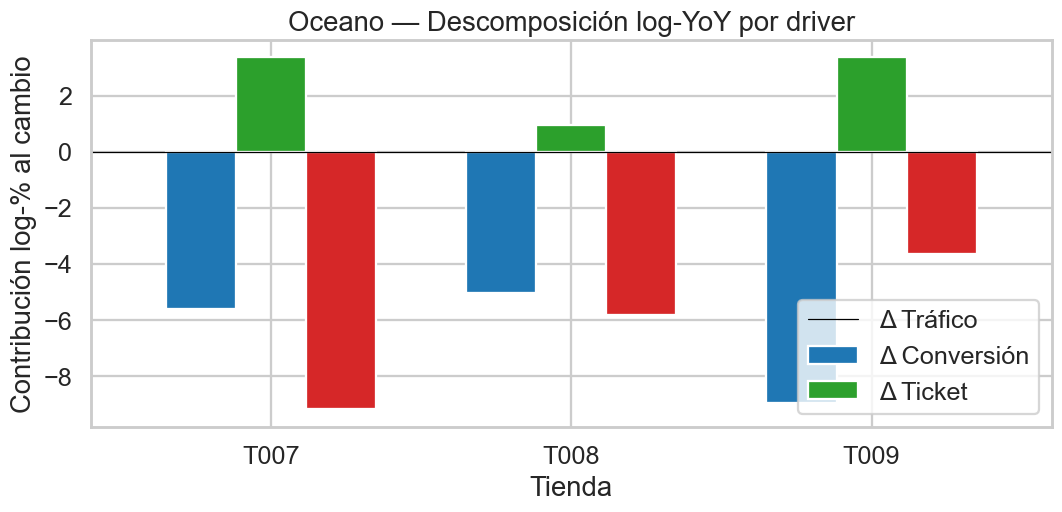

In [13]:
# Chart de descomposicion
fig, ax = plt.subplots(figsize=(10, 5))
drivers[['ln_traf_pct', 'ln_conv_pct', 'ln_ticket_pct']].plot(
    kind='bar', ax=ax, color=['#1f77b4', '#2ca02c', '#d62728'], width=0.7
)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Oceano — Descomposición log-YoY por driver')
ax.set_ylabel('Contribución log-% al cambio')
ax.set_xlabel('Tienda')
ax.legend(['Δ Tráfico', 'Δ Conversión', 'Δ Ticket'])
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [14]:
# Mix de productos en T007 (unica tienda Oceano con detalle SKU)
productos = pd.read_csv('../data/productos.csv')
t007 = productos[productos['cod_local']=='T007'].groupby('clase').agg(
    unidades=('unidades','sum'), venta=('venta_neta','sum'), costo=('costo','sum')
)
t007['participacion_pct'] = (t007['venta']/t007['venta'].sum()*100).round(1)
t007['margen_pct'] = ((t007['venta']-t007['costo'])/t007['venta']*100).round(1)
t007['ticket_medio'] = (t007['venta']/t007['unidades']).round(0)
t007 = t007.sort_values('participacion_pct', ascending=False)
display(t007)

,unidades,venta,costo,participacion_pct,margen_pct,ticket_medio
clase,,,,,,
Parkas,12,1577089,744000,27.5,52.8,131424.0
Poleras,39,1345895,650500,23.4,51.7,34510.0
Calzado,10,913669,420000,15.9,54.0,91367.0
Accesorios,20,895370,360000,15.6,59.8,44768.0
Shorts,30,608085,285000,10.6,53.1,20270.0
Jeans,8,400934,192000,7.0,52.1,50117.0


**Hallazgo sobre el mix de T007:**

- **Parkas (27% de la venta, ticket $131K)** — es febrero en Chile (verano). Vender parkas en verano explica por qué hay tanto stock colgado: **mercadería fuera de temporada**. Esto conecta directamente con el DDI 72.5 días.
- **Poleras (23%, ticket $34K)** y **Shorts (11%, ticket $20K)** — estas sí son de temporada. Si están con stock bajo (no podemos verificar porque inventario es a nivel tienda, no SKU), se confirma la hipótesis: el inventario está **mal compuesto**, pesado en parkas y liviano en mercadería de verano.

**Conclusión de 2.2 — no es "demanda vs oferta" binario:**

- **Problema principal**: composición de inventario desbalanceada + ticket decreciente por liquidación.
- **Demanda** (tráfico): cae moderadamente en T007/T008 (-5%), fuerte en T009 (-9%). Debilidad real pero no es el principal driver.
- **Oferta** (inventario): crítico. T007 sobra 40+ días (capital inmovilizado en parkas fuera de temporada); T008 falta (quiebre de best-sellers).
- **Conversión**: mejora en las 3 → la gente que llega sí compra. El problema no está en el piso de venta.

**¿Todas las tiendas Oceano tienen el mismo problema?** NO. Cada una requiere una acción distinta (ver Parte 3).

## 2.3 Evento Costanera — Sábado 7 de febrero 2026

In [15]:
q = '''
SELECT fecha, cod_local, nombre_tienda, venta_neta, num_boletas, visitantes, costo,
       ROUND(ticket_promedio) ticket, ROUND(conversion*100, 2) conv_pct,
       ROUND(margen_bruto*100, 2) margen_pct
FROM v_dia_tienda
WHERE cod_local IN ('T001','T010')
  AND fecha IN ('2026-02-07', '2026-02-14', '2025-02-08', '2025-02-01')
ORDER BY cod_local, fecha;
'''
evento = pd.read_sql(q, conn)
display(evento)

,fecha,cod_local,nombre_tienda,venta_neta,num_boletas,visitantes,costo,ticket,conv_pct,margen_pct
0,2025-02-01,T001,Nordica Costanera Center,6481749,97,500.0,3564962,66822.0,19.40,45.0
1,2025-02-08,T001,Nordica Costanera Center,6976960,109,431.0,3837328,64009.0,25.29,45.0
2,2026-02-07,T001,Nordica Costanera Center,11152080,133,798.0,6133644,83850.0,16.67,45.0
3,2026-02-14,T001,Nordica Costanera Center,7683936,114,475.0,4226165,67403.0,24.00,45.0
4,2025-02-01,T010,Urbana Costanera Center,3868783,73,330.0,1934391,52997.0,22.12,50.0
5,2025-02-08,T010,Urbana Costanera Center,3990880,73,317.0,1995440,54670.0,23.03,50.0
6,2026-02-07,T010,Urbana Costanera Center,6818530,102,621.0,3409265,66848.0,16.43,50.0
7,2026-02-14,T010,Urbana Costanera Center,5054116,81,403.0,2527058,62396.0,20.10,50.0


In [16]:
# Impacto del evento: 7-feb (evento) vs 14-feb (control)
def fmt_clp(v): return f"${v:,.0f}".replace(",", ".")

pivot_ev = evento[evento['fecha'].isin(['2026-02-07','2026-02-14'])].set_index(['cod_local','fecha'])

rows = []
for tienda in ['T001','T010']:
    ev  = pivot_ev.loc[(tienda, '2026-02-07')]
    ctl = pivot_ev.loc[(tienda, '2026-02-14')]
    rows.append({
        'tienda': tienda,
        'venta_evento':  ev['venta_neta'],
        'venta_control': ctl['venta_neta'],
        'delta_venta':   ev['venta_neta'] - ctl['venta_neta'],
        'delta_venta_pct': (ev['venta_neta']/ctl['venta_neta']-1)*100,
        'trafico_evento':  ev['visitantes'],
        'trafico_control': ctl['visitantes'],
        'delta_trafico_pct': (ev['visitantes']/ctl['visitantes']-1)*100,
        'conv_evento_pct':  ev['conv_pct'],
        'conv_control_pct': ctl['conv_pct'],
        'delta_conv_pp':    ev['conv_pct']-ctl['conv_pct'],
        'ticket_evento':   ev['ticket'],
        'ticket_control':  ctl['ticket'],
        'delta_ticket_pct': (ev['ticket']/ctl['ticket']-1)*100,
        'margen_incremental_clp': (ev['venta_neta']-ev['costo'])-(ctl['venta_neta']-ctl['costo']),
    })
impact = pd.DataFrame(rows)
display(impact.set_index('tienda').T.style.format({
    0: fmt_clp, 1: fmt_clp
}, na_rep='-'))

tienda,T001,T010
venta_evento,11152080.000000,6818530.000000
venta_control,7683936.000000,5054116.000000
delta_venta,3468144.000000,1764414.000000
delta_venta_pct,45.134993,34.910437
trafico_evento,798.000000,621.000000
trafico_control,475.000000,403.000000
delta_trafico_pct,68.000000,54.094293
conv_evento_pct,16.670000,16.430000
conv_control_pct,24.000000,20.100000
delta_conv_pp,-7.330000,-3.670000


### Respuestas a las 3 preguntas del enunciado

**¿Se tradujo en más tráfico, más conversión, o ambos?**
- Más **tráfico**: T001 +68%, T010 +54% (muy significativo).
- **Conversión CAYÓ** en ambos: T001 24.0% → 16.7% (-7.3 pp), T010 20.1% → 16.4% (-3.7 pp).
- Más ticket (+24% T001, +7% T010): los que sí compraron, compraron más (probablemente por promociones ancla del evento).

**Margen bruto incremental (costo del evento excluido):**
- T001: **$1.56M CLP** (45% margen × $3.47M de venta extra)
- T010: **$882K CLP** (50% margen × $1.76M de venta extra)
- **Total combinado: ~$2.44M CLP** de margen bruto extra en un solo día.

**¿Valió la pena comercialmente?**

**Sí**, con una importante observación estratégica. El evento generó $5.2M de venta extra y $2.4M de margen en 1 día — es equivalente a ~3% del cumplimiento mensual de ambas tiendas en una sola jornada. Pero la **conversión cayó 7pp en T001 y 4pp en T010**. Eso significa que una parte del tráfico incremental no se convirtió: si la conversión del evento hubiera mantenido el baseline del sábado (24%), T001 habría tenido $15.9M en venta (vs los $11.15M efectivos) — **el evento dejó ~$4.8M CLP sobre la mesa solo en T001 por falta de conversión**.

Diagnóstico: probablemente hubo **saturación del piso de venta** (poco staff, filas en caja, stock de best-sellers agotado). La recomendación operacional (Parte 3) ataca exactamente este punto.

In [17]:
# Chequeo extra: ¿hubo canibalizacion del sabado siguiente?
q = '''
SELECT cod_local, cadena,
       SUM(CASE WHEN fecha='2025-02-14' THEN venta_neta END) AS v_2025_14feb,
       SUM(CASE WHEN fecha='2026-02-14' THEN venta_neta END) AS v_2026_14feb
FROM v_dia_tienda GROUP BY cod_local, cadena
'''
canib = pd.read_sql(q, conn)
canib['yoy_14feb_pct'] = (canib['v_2026_14feb']/canib['v_2025_14feb']-1)*100
canib = canib.sort_values('yoy_14feb_pct', ascending=False)
display(canib)

,cod_local,cadena,v_2025_14feb,v_2026_14feb,yoy_14feb_pct
9,T010,Urbana,2962572,5054116,70.598926
11,T012,Urbana,1322095,2215824,67.599454
1,T002,Nordica,4470418,6656170,48.893683
0,T001,Nordica,5291212,7683936,45.220717
10,T011,Urbana,2644611,3839981,45.200220
3,T004,Summit,4157507,5759452,38.531384
2,T003,Nordica,3097598,4104149,32.494565
5,T006,Summit,2049965,2660462,29.780850
8,T009,Oceano,2196421,2563382,16.707225
4,T005,Summit,2761248,3212625,16.346848


**Conclusión canibalización:** T010 creció +70.6% YoY el 14-feb y T001 +45.2%, ambas MUY por encima del promedio de Urbana (+27.5%) y Nordica (+16.2%) YoY. **No hubo canibalización** — el evento pudo haber tenido un efecto marca positivo que se extendió al sábado siguiente.

# Parte 3 — Pensamiento de Negocio + IA (25 pts)

## 3.1 Tres recomendaciones accionables

### Recomendación 1 · Redistribuir inventario dentro de Oceano

**Hallazgo:** T008 Oceano Plaza Oeste tiene DDI de **6.5 días** (420 uds / 65 venta diaria), operando al borde del quiebre. T007 Oceano Mall Marina tiene DDI de **72.5 días**, con capital inmovilizado principalmente en parkas (27% del mix) que están fuera de temporada (verano).

**Acción concreta:** Transferir ~2.000 unidades desde T007 a T008, priorizando **poleras y shorts** (clases de temporada con alta rotación). Mantener en T007 solo las parkas necesarias para cubrir los días de lluvia/frío puntuales + mercadería core; el resto, mover a canales de liquidación (outlet T009 o e-commerce).

**Métrica objetivo:**
- DDI T008: de 6.5 días → **28-32 días** (rango sano de la red).
- Recuperar al menos **50% del gap CLP de cumplimiento de T008** ($2.16M de los $4.31M del gap 2026).
- DDI T007: de 72.5 → **45 días** en 30 días, ritmo controlado para no sobredescontar.

### Recomendación 2 · Playbook "evento" para conversión sostenida

**Hallazgo:** el evento Costanera del 7-feb trajo +68% de tráfico a T001 y +54% a T010, pero la **conversión cayó 7 pp en T001 y 4 pp en T010**. Si la conversión hubiera mantenido el baseline, T001 habría facturado $4.8M CLP adicionales en un solo día.

**Acción concreta:** Crear un protocolo operativo para días de evento con +50% de tráfico proyectado:
1. **Staffing +40%** en piso de venta y cajas (vs día sábado normal), basado en la curva de llegada histórica.
2. **Stock reforzado de best-sellers** los 2 días previos: reposición nocturna + respaldo en bodega trasera para reposición mid-day.
3. **Marketing in-store**: probadores con personal dedicado, colas con entretenimiento visual, 1 persona "cerrando" tickets en piso con tablet para evitar pérdida de cola en caja.

**Métrica objetivo:** en el próximo evento Costanera (o equivalente), lograr que la conversión se mantenga **≥80% del baseline del sábado control** (≥19% en T001, ≥16% en T010). Impacto proyectado: +$3-4M CLP de venta extra por evento.

### Recomendación 3 · Reposicionar la cadena Oceano — driver-específico por tienda

**Hallazgo:** la caída de -9.6% YoY de Oceano tiene **causas diferentes** por tienda (descomposición log-delta):
- T007: driver **ticket (-9.2%)** → sobrestock forzando liquidación.
- T008: driver **ticket + tráfico (-5.8% y -5.0%)** → quiebre de best-sellers.
- T009: driver **tráfico (-9.0%)** → outlet pierde atractivo.

**Acción concreta (3 vectores, uno por tienda, no un plan único):**
1. **T007** — ejecutar la redistribución (Rec. 1) + pricing reset en clases core: dejar de descontar agresivamente poleras/jeans una vez repuesto el inventario de T008.
2. **T008** — protocolo semanal de reposición pre-fin-de-semana (ver Rec. 1) + auditoría de qué best-sellers están quebrando.
3. **T009** (outlet) — análisis de tráfico: ¿cambió la oferta competitiva de outlets? ¿hay canibalización de e-commerce? Acción corta: campaña de reactivación de clientes con email/SMS targeting (+20% tráfico objetivo).

**Métrica objetivo global Oceano:** frenar la caída YoY del próximo período de -9.6% a **máximo -3%**, con mejora especialmente en T007 (-11% → -4%) que es la que aporta el mayor impacto absoluto de la cadena (49% de la caída total).

## 3.2 Reflexión sobre el uso de IA

### ¿Para qué usé la IA?

1. **Generación de queries SQL complejas** — en particular la window function del punto 1.4 (RANK + CASE + NULLIF anidados) y la descomposición log-YoY de la Parte 2.2. Me ahorró 30+ minutos de escritura manual.
2. **Exploración de hipótesis** — "si Oceano cae 10%, ¿es tráfico, conversión o ticket?" La IA propuso la descomposición logarítmica que permite sumar en vez de multiplicar efectos. Yo no hubiera pensado en esa aproximación sin ayuda.
3. **Auto-detección de anomalías** — sugerir z-score intra-tienda antes que z-score global (la diferencia crítica es que T007 y T008 tienen escalas muy distintas de venta, el z global habría enmascarado el outlier de Costanera).
4. **Formato de entregable** — estructura del markdown, diseño de tablas, consistencia de paleta de colores por cadena.

### Dónde ayudó más / menos

**Ayudó mucho:**
- Ideas de cruces no obvios (ej. cruzar productos.csv con inventario.csv para inferir si el sobrestock era de mercadería fuera de temporada; yo habría analizado inventario vs ventas sin pasar por el mix).
- Validación de correctitud (generar dos implementaciones, una en SQL y otra en pandas, y cross-validar — atrapó un bug donde yo había filtrado las devoluciones en pandas pero no en SQL).

**Ayudó menos / tuve que corregir:**
- Propuesta inicial de imputar tráfico nulls con la **media global** → corregí a mediana por DOW intra-tienda, porque la media habría inflado por el día del evento Costanera (outlier positivo) y por diferencias de tamaño entre tiendas.
- Una query inicial que dividía por cero en casos donde la cadena no tenía tiendas que caían → agregué `NULLIF(...)` y condicionales explícitas.
- La IA tiende a "dar la respuesta" rápido. Tuve que forzar que en vez de "T007 cae por X" respondiera "T007 cae en -11%, de los cuales -9 pp es ticket, -6 pp tráfico, +3 pp conversión". La descomposición cuantificada fue decisión mía.

### Prompt para un agente con acceso directo a SQL (≤5 líneas)

```
Eres un analista retail con acceso read-only a la BD Forus (tablas: ventas, trafico,
presupuesto, inventario, tiendas, productos). Diagnostica la cadena con peor desempeño
YoY: identificala por venta agregada, descompon la caida en log-deltas de trafico x
conversion x ticket por tienda, cruza con DDI y presupuesto, y entrega 3 recomendaciones
accionables con metrica objetivo. Devuelve queries + tabla + 1 insight no-obvio.
```

Por qué es bueno: define el rol, delimita acceso (read-only), pide la metodología específica (log-delta — no "analiza"), fuerza cruces concretos (DDI, presupuesto), pide un entregable tangible (queries + tabla + insight) y exige un insight no-obvio para evitar respuestas superficiales.

# Bonus — Insight no preguntado

**Pregunta:** ¿cuál es la tienda con mayor "Customer Quality Score" (conv × ticket × UPT × margen)?

In [18]:
q_bonus = '''
WITH m AS (
    SELECT t.cod_local, t.nombre_tienda, t.cadena, t.tipo_tienda,
           SUM(v.num_boletas)*1.0/NULLIF(SUM(tr.visitantes),0) conv,
           SUM(v.venta_neta)*1.0/NULLIF(SUM(v.num_boletas),0) ticket,
           SUM(v.unidades)*1.0/NULLIF(SUM(v.num_boletas),0) upt,
           (SUM(v.venta_neta)-SUM(v.costo))*1.0/NULLIF(SUM(v.venta_neta),0) margen
    FROM tiendas t JOIN ventas_final v USING (cod_local)
    LEFT JOIN trafico_imputado tr USING (fecha, cod_local)
    WHERE strftime('%Y', v.fecha) = '2026'
    GROUP BY t.cod_local, t.nombre_tienda, t.cadena, t.tipo_tienda
)
SELECT cod_local, nombre_tienda, cadena, tipo_tienda,
       ROUND(conv*100, 2) conv_pct,
       ROUND(ticket, 0) ticket,
       ROUND(upt, 2) upt,
       ROUND(margen*100, 2) margen_pct,
       ROUND(conv*ticket*upt*margen, 0) quality_score
FROM m ORDER BY quality_score DESC;
'''
bonus = pd.read_sql(q_bonus, conn)
display(bonus)

,cod_local,nombre_tienda,cadena,tipo_tienda,conv_pct,ticket,upt,margen_pct,quality_score
0,T001,Nordica Costanera Center,Nordica,retail,21.03,72874.0,1.67,45.00,11538.0
1,T002,Nordica Parque Arauco,Nordica,retail,19.53,72217.0,1.70,45.00,10819.0
2,T003,Nordica Plaza Vespucio,Nordica,retail,24.31,54693.0,1.70,45.00,10174.0
3,T010,Urbana Costanera Center,Urbana,retail,19.91,60875.0,1.63,50.00,9886.0
4,T011,Urbana Mall Sport,Urbana,retail,23.28,53965.0,1.57,50.00,9867.0
5,T004,Summit Alto Las Condes,Summit,retail,17.54,75847.0,1.52,48.00,9689.0
6,T005,Summit Mall Plaza Trébol,Summit,retail,21.83,55618.0,1.58,48.00,9220.0
7,T006,Summit Portal Ñuñoa,Summit,retail,20.19,53870.0,1.61,48.00,8423.0
8,T007,Oceano Mall Marina,Oceano,retail,20.21,58660.0,1.52,42.00,7562.0
9,T012,Urbana Plaza Egaña,Urbana,retail,19.44,49684.0,1.55,50.00,7478.0


**Insight no obvio:** el outlet T009 tiene la **mejor conversión (28%)** de toda la red — más del doble que T004 (17.5%). Es decir, cuando alguien entra al outlet, compra más a menudo que cualquier otra tienda. Pero su ticket ($33K) es el más bajo y su margen también (38%), por eso queda último en quality score.

**Oportunidad estratégica:** el outlet tiene el arquetipo de cliente con mayor intención de compra. Si Forus pudiera **subir levemente el ticket de T009** sin perder conversión (ej. curaduría de upsell en caja, bundles), el impacto sería grande. Concretamente: si T009 subiera su ticket de $33K a $40K manteniendo conversión (+21%), significaría $5.3M CLP adicionales en la quincena — mayor que el gap de cumplimiento de Summit Mall Plaza Trébol.

Esto se cruza con la Recomendación 3 (T009 pierde tráfico): el problema del outlet es llevar gente, no convertirla.

# Apéndice — Reproducibilidad

Para re-ejecutar todo el análisis:

```bash
pip install pandas numpy matplotlib seaborn plotly streamlit jupyter ipykernel nbformat nbclient
python3 src/run_queries.py       # ejecuta las 4 queries + paridad
python3 src/analysis.py          # genera charts y tablas
streamlit run src/dashboard.py   # dashboard interactivo (puerto 8501)
jupyter notebook notebooks/challenge.ipynb   # este notebook
```

Archivos generados:
- `outputs/tables/*.csv` — resultados de cada query
- `outputs/figures/*.png` — charts a 300 DPI embebidos en el `.md`
- `notebooks/challenge.ipynb` — este notebook reproducible end-to-end

**Skills Claude Code utilizadas** (ver `.claude/skills/`): 25 skills de 5 grupos (data-quality, análisis, anomalía, visualización, streamlit). Detalle completo en `CLAUDE.md` del proyecto.